<a href="https://colab.research.google.com/github/Yashcode007/pytorch/blob/main/mnist_flow_scratch_AI395T.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TODO

Try flow MNIST with UNet

In [1]:
!git clone https://github.com/lqiang67/rectified-flow.git
%cd rectified-flow/

Cloning into 'rectified-flow'...
remote: Enumerating objects: 1423, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 1423 (delta 89), reused 83 (delta 68), pack-reused 1250 (from 1)
Receiving objects: 100% (1423/1423), 58.05 MiB | 22.52 MiB/s, done.
Resolving deltas: 100% (911/911), done.
/content/rectified-flow


In [8]:
import math
import numpy as np
import torch
import torch.utils.checkpoint
import torchvision
import matplotlib.pyplot as plt

from torchvision import transforms
from tqdm.auto import tqdm

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.utils import match_dim_with_data
from rectified_flow.utils import plot_cifar_results

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

## Load dataset

In [9]:
batch_size = 512

transform_list = [
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
]
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transforms.Compose(transform_list)
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)

batch = next(iter(train_dataloader))
print(batch[0].shape)  # torch.Size([256, 1, 28, 28])

torch.Size([512, 1, 28, 28])


## Train Unconditional Generation

In [10]:
import copy
import os
import torch

class EMAModel:
    def __init__(
        self,
        net: torch.nn.Module,
        ema_halflife_kimg: float = 2000.0,
        ema_rampup_ratio: float = 0.05,
    ):
        self.net = net
        self.ema = copy.deepcopy(net).eval().float()
        for param in self.ema.parameters():
            param.requires_grad_(False)
        self.ema_halflife_kimg = ema_halflife_kimg
        self.ema_rampup_ratio = ema_rampup_ratio

    @torch.no_grad()
    def update(self, cur_nimg: int, batch_size: int):
        """
        Update EMA parameters using a half-life strategy.

        Args:
            cur_nimg (int): The current number of images (could be total images processed so far).
            batch_size (int): The global batch size.
        """
        ema_halflife_nimg = self.ema_halflife_kimg * 1000

        if self.ema_rampup_ratio is not None:
            ema_halflife_nimg = min(ema_halflife_nimg, cur_nimg * self.ema_rampup_ratio)

        beta = 0.5 ** (batch_size / max(ema_halflife_nimg, 1e-8))

        for p_ema, p_net in zip(self.ema.parameters(), self.net.parameters()):
            p_ema.copy_((p_net.float()).lerp(p_ema, beta))

    def apply_shadow(self):
        """
        Copy EMA parameters back to the original `net`.
        """
        for p_net, p_ema in zip(self.net.parameters(), self.ema.parameters()):
            p_net.data.copy_(p_ema.data.to(p_net.dtype))

    def save_pretrained(self, save_directory: str, filename: str = "unet"):
        """
        Save the EMA model parameters to a file.
        """
        if not os.path.exists(save_directory):
            os.makedirs(save_directory)
        state_dict_cpu = {k: v.cpu() for k, v in self.ema.state_dict().items()}
        output_model_file = os.path.join(save_directory, f"{filename}_ema.pt")
        torch.save(state_dict_cpu, output_model_file)
        print(f"EMA model weights saved to {output_model_file}")

    def load_pretrained(self, save_directory: str, filename: str = "unet"):
        """
        Load EMA model parameters from a file.
        """
        output_model_file = os.path.join(save_directory, f"{filename}_ema.pt")
        if os.path.exists(output_model_file):
            state_dict = torch.load(output_model_file, map_location="cpu")
            self.ema.load_state_dict(state_dict, strict=True)
            net_device = next(self.net.parameters()).device
            self.ema.to(device=net_device, dtype=torch.float32)
            print(f"EMA weights loaded from {output_model_file}")
        else:
            print(f"No EMA weights found at {output_model_file}")

In [11]:
from rectified_flow.models.unet import SongUNet, SongUNetConfig
config = SongUNetConfig(
    img_resolution = 28,
    in_channels = 1,                  # Number of color channels at input.
    out_channels = 1,                 # Number of color channels at output.
    label_dim = 0,                    # Number of class labels, 0 = unconditional.
    augment_dim = 0,                  # Augmentation label dimensionality, 0 = no augmentation.

    model_channels = 64,                # Base multiplier for the number of channels.
    channel_mult = [2, 2],              # Channel multipliers for each resolution.
    channel_mult_emb = 2,               # Multiplier for the dimensionality of the embedding vector.
    num_blocks = 2,                     # Number of residual blocks per resolution.
    attn_resolutions = [14],            # Resolutions at which to apply attention.
    dropout = 0.13,                     # Dropout probability of intermediate activations.
    label_dropout = 0.0,                # Dropout probability of class labels for classifier-free guidance.
    embedding_type = "positional",      # Timestep embedding type: 'positional' or 'fourier'.
    channel_mult_time = 1,              # Timestep embedding size: 1 for DDPM++, 2 for NCSN++.
    encoder_type = "standard",          # Encoder architecture: 'standard' or 'residual'.
    decoder_type = "standard",          # Decoder architecture: 'standard' or 'residual'.
    resample_filter = [1, 1]
)
flow_model = SongUNet(config)
data_shape = (1, 28, 28)
flow_model = flow_model.to(device)

print(f"Number of parameters in flow model: {sum(p.numel() for p in flow_model.parameters() if p.requires_grad):,}")

ema_flow = EMAModel(flow_model, ema_halflife_kimg=1.0, ema_rampup_ratio=0.05)

optimizer = torch.optim.AdamW(
    flow_model.parameters(),
    lr=5e-4, weight_decay=0.01,
    betas=(0.9, 0.95)
)

compiled_flow = torch.compile(flow_model, mode="reduce-overhead", fullgraph=False, dynamic=False)

compiled_flow.train()
optimizer.zero_grad()

Number of parameters in flow model: 5,631,873


In [12]:
epoch = 30
# If you have A100 GPU, can set epoch to 200
cur_nimg = 0

try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm

def safe_tqdm_write(msg: str):
    try:
        tqdm.write(msg)
    except Exception:
        print(msg)

zero_to_none = True
grad_clip_norm = None

global_step = 0
running_loss = None
smooth_alpha = 0.99

train_stats = {
    "epoch_loss": [],
    "iteration_loss": [],
    "avg_epoch_loss": [],
}

# test model
with torch.no_grad():
    batch = next(iter(train_dataloader))
    x_1, c = batch
    x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
    x_0 = torch.randn_like(x_1)
    t = torch.rand(x_1.shape[0], device=x_1.device)
    v_pred = flow_model(x_1, t)
    sq_err = (v_pred - (x_1 - x_0)).pow(2).sum(dim=1)
    loss = sq_err.mean()
    print(x_1.shape, x_0.shape, v_pred.shape)
    safe_tqdm_write(f"Initial test loss: {loss.item():.4f}")

torch.Size([512, 1, 28, 28]) torch.Size([512, 1, 28, 28]) torch.Size([512, 1, 28, 28])
Initial test loss: 1.9277


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

ep 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

Configuration saved to ./checkpoints/flow_mnist/flow_mnist_ep1_config.json
Model weights saved to ./checkpoints/flow_mnist/flow_mnist_ep1_model.pt
EMA model weights saved to ./checkpoints/flow_mnist/flow_mnist_ep1_ema.pt
[epoch 1/30] steps=118 epoch_loss=57.3771 avg_epoch_loss=0.4862 mse_loss_ema=0.8895


ep 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 2/30] steps=236 epoch_loss=58.3831 avg_epoch_loss=0.4948 mse_loss_ema=0.6165


...

[epoch 28/30] steps=3,304 epoch_loss=78.9802 avg_epoch_loss=0.6693 mse_loss_ema=0.7043


ep 29/30:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 29/30] steps=3,422 epoch_loss=78.6139 avg_epoch_loss=0.6662 mse_loss_ema=0.6780


ep 30/30:   0%|          | 0/118 [00:00<?, ?it/s]

Configuration saved to ./checkpoints/flow_mnist/flow_mnist_ep30_config.json
Model weights saved to ./checkpoints/flow_mnist/flow_mnist_ep30_model.pt
EMA model weights saved to ./checkpoints/flow_mnist/flow_mnist_ep30_ema.pt
[epoch 30/30] steps=3,540 epoch_loss=92.0123 avg_epoch_loss=0.7798 mse_loss_ema=0.7562
Training done. Total steps: 3,540, last loss: 0.7875, EMA: 0.7562


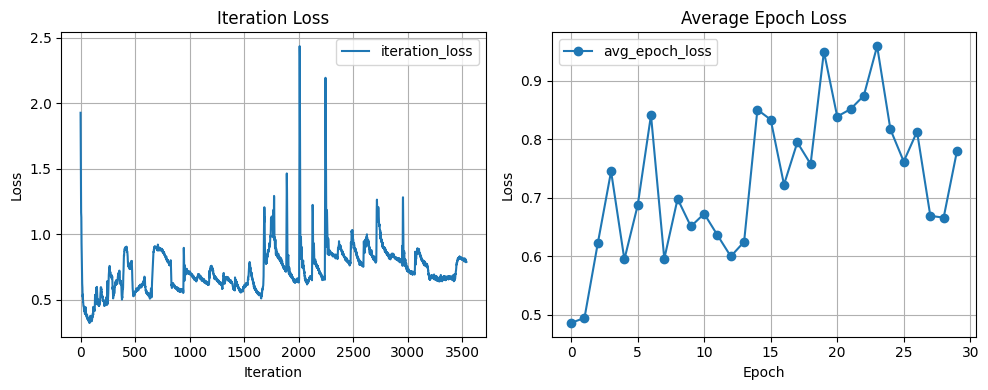

In [13]:
for ep in tqdm(range(epoch), desc="Epochs", position=0):
    compiled_flow.train()
    pbar = tqdm(train_dataloader, desc=f"ep {ep+1}/{epoch}", leave=False, position=1)
    epoch_loss = 0.0
    epoch_steps = 0

    for step, batch in enumerate(pbar):
        optimizer.zero_grad(set_to_none=zero_to_none)

        x_1, c = batch
        x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
        x_0 = torch.randn_like(x_1)

        B = x_1.shape[0]
        t = torch.rand(B, device=x_1.device, dtype=x_1.dtype)
        t_b = t.view(B, 1, 1, 1)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            x_t = t_b * x_1 + (1 - t_b) * x_0
            dot_x_t = x_1 - x_0
            v_pred = compiled_flow(x_t, t)

        loss = torch.nn.functional.mse_loss(v_pred.float(), dot_x_t.float())

        loss.backward()
        optimizer.step()

        global_step += 1
        cur_nimg += B
        ema_flow.update(cur_nimg=cur_nimg, batch_size=B)

        loss_val = float(loss.detach().item())
        epoch_loss += loss_val
        epoch_steps += 1
        train_stats["iteration_loss"].append(loss_val)

        running_loss = loss_val if running_loss is None else (
            smooth_alpha * running_loss + (1 - smooth_alpha) * loss_val
        )

        pbar.set_postfix({
            "mse_loss": f"{loss_val:.4f}",
            "mse_loss_ema": f"{running_loss:.4f}",
            "steps": global_step
        })

    avg_epoch_loss = epoch_loss / max(epoch_steps, 1)
    train_stats["epoch_loss"].append(epoch_loss)
    train_stats["avg_epoch_loss"].append(avg_epoch_loss)

    checkpoint_dir = "./checkpoints/flow_mnist"
    os.makedirs(checkpoint_dir, exist_ok=True)
    if ep % 10 == 0 or ep == epoch - 1:
        flow_model.save_pretrained(checkpoint_dir, filename=f"flow_mnist_ep{ep+1}")
        ema_flow.save_pretrained(checkpoint_dir, filename=f"flow_mnist_ep{ep+1}")

    safe_tqdm_write(
        f"[epoch {ep+1}/{epoch}] steps={global_step:,} "
        f"epoch_loss={epoch_loss:.4f} avg_epoch_loss={avg_epoch_loss:.4f} "
        f"mse_loss_ema={running_loss:.4f}"
    )

print(f"Training done. Total steps: {global_step:,}, last loss: {loss_val:.4f}, EMA: {running_loss:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_stats["iteration_loss"], label="iteration_loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Iteration Loss")
plt.grid(True)
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_stats["avg_epoch_loss"], marker="o", label="avg_epoch_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Average Epoch Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
from rectified_flow.samplers import EulerSampler, SDESampler
import os

checkpoint_dir = "./checkpoints/flow_mnist"
checkpoint_file = os.path.join(checkpoint_dir, "flow_mnist_ep30_model.pt")

if os.path.exists(checkpoint_file):
    # Load trained model
    flow_model = SongUNet.from_pretrained(
        checkpoint_dir,
        filename="flow_mnist_ep30",
        use_ema=False
    ).to(device)

    # Load EMA weights
    ema_flow.load_pretrained(
        checkpoint_dir,
        filename="flow_mnist_ep30"
    )

    # Copy EMA weights into the model
    ema_flow.apply_shadow()

    print(f"Loaded checkpoint from {checkpoint_file}")

else:
    print(f"Checkpoint not found at {checkpoint_file}. Using current model state.")
    ema_flow.apply_shadow()

flow_model.eval()

model_inference = flow_model

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=model_inference,
    device=device,
)

num_steps_list = [2, 5, 10, 20, 50, 100]
num_samples = 100

euler_sampler = EulerSampler(
    rf_inference,
    num_steps=num_steps_list[-1]
)

sde_sampler = SDESampler(
    rf_inference,
    num_steps=num_steps_list[-1],
    noise_scale=5,
    noise_decay_rate=0.0,
)

Model loaded from ./checkpoints/flow_mnist/flow_mnist_ep30_model.pt
EMA weights loaded from ./checkpoints/flow_mnist/flow_mnist_ep30_ema.pt
Loaded checkpoint from ./checkpoints/flow_mnist/flow_mnist_ep30_model.pt


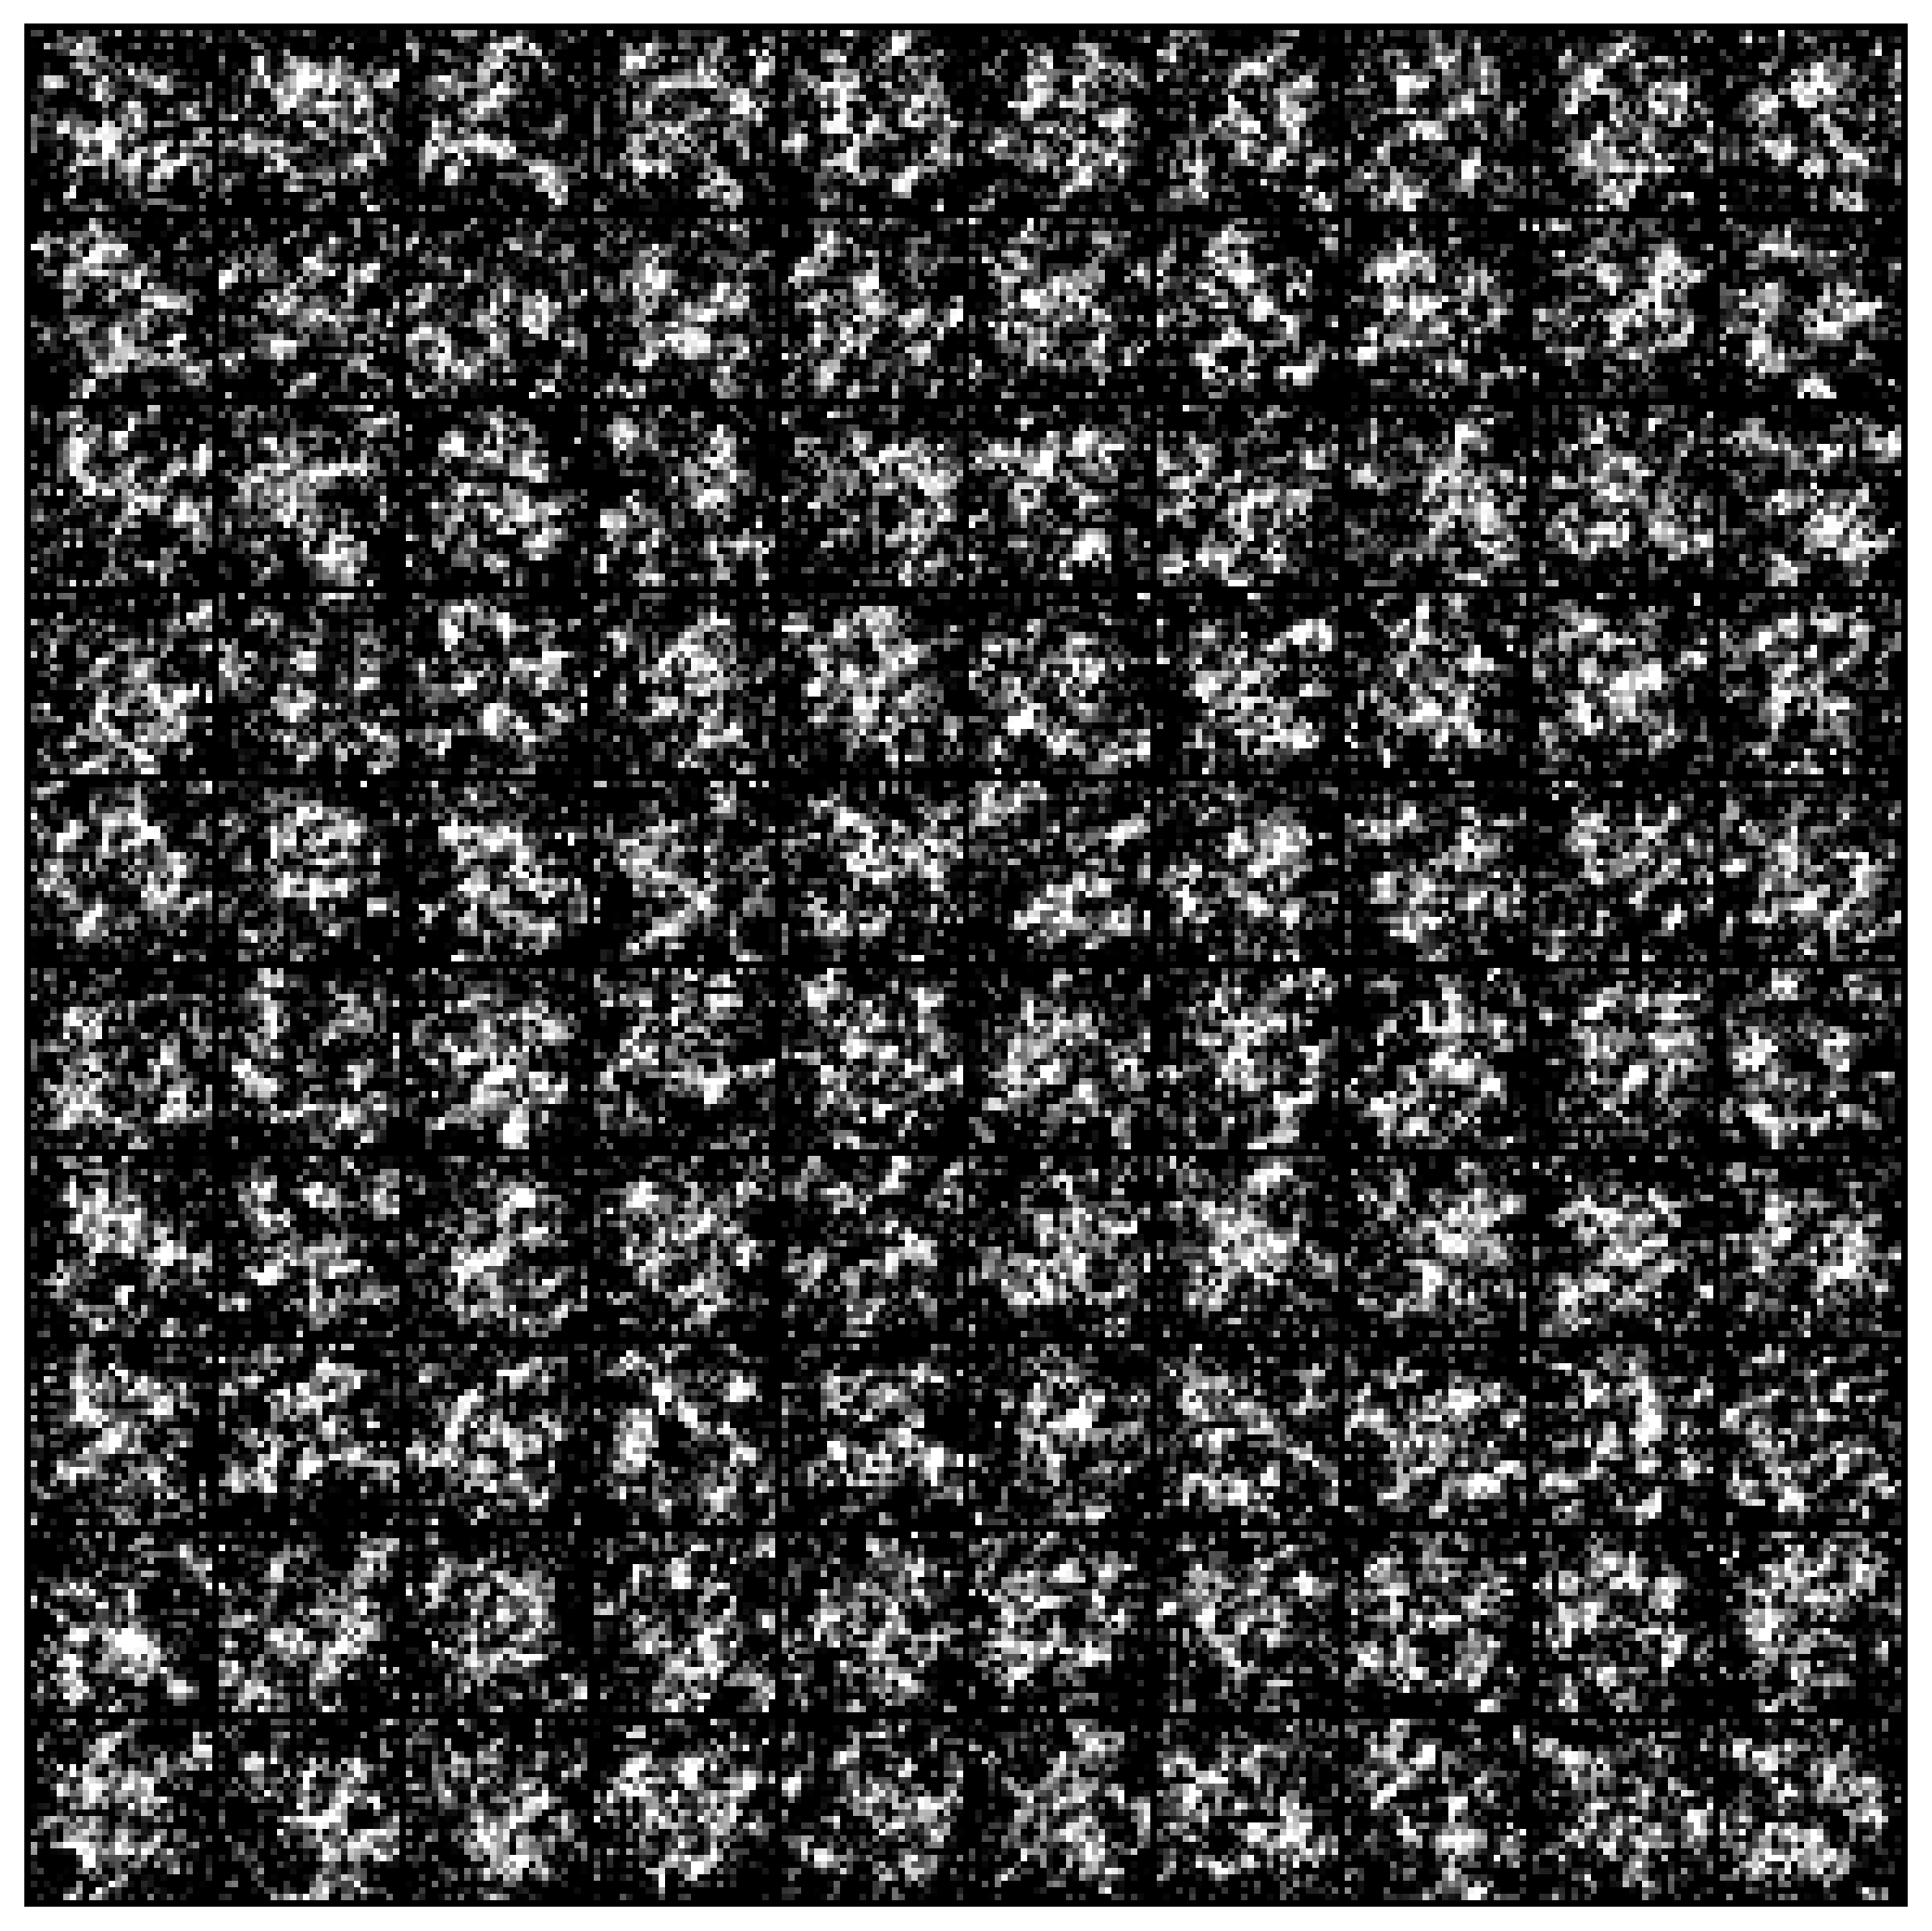

In [16]:
x_0 = torch.randn(100, *data_shape).to(device)

x_t = x_0.clone()

N = 100

# Implement Euler Sampler
with torch.inference_mode():
    for i in range(N):
        t = torch.full((x_0.shape[0],), float(i) / N, device=x_0.device, dtype=x_0.dtype)
        v_pred = flow_model(x_t, t)
        x_t = x_t + v_pred * (1.0 / N)

plot_cifar_results(x_t)


In [17]:
x_0 = torch.randn(30, *data_shape).to(device) * 0.5

x_1_euler = euler_sampler.sample_loop(x_0=x_0).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(x_0=x_0).trajectories[-1]

print(x_1_euler.shape)  # torch.Size([30, 1, 28, 28])

torch.Size([30, 1, 28, 28])


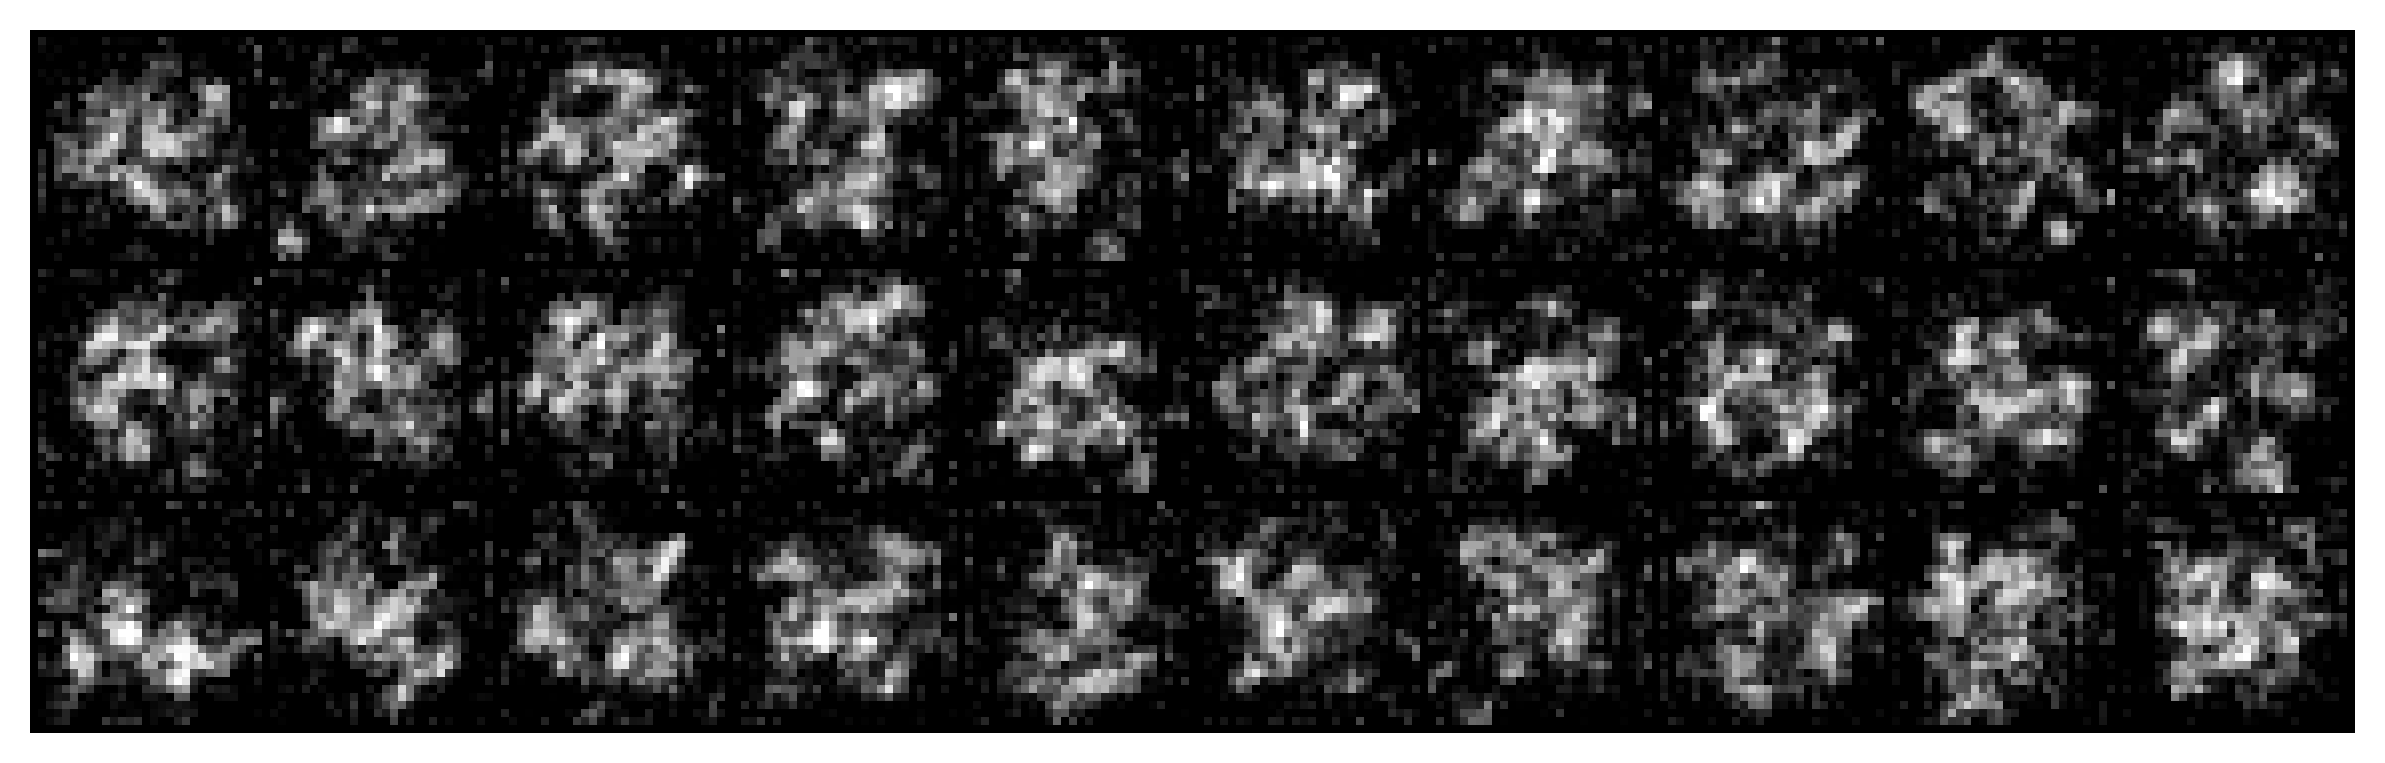

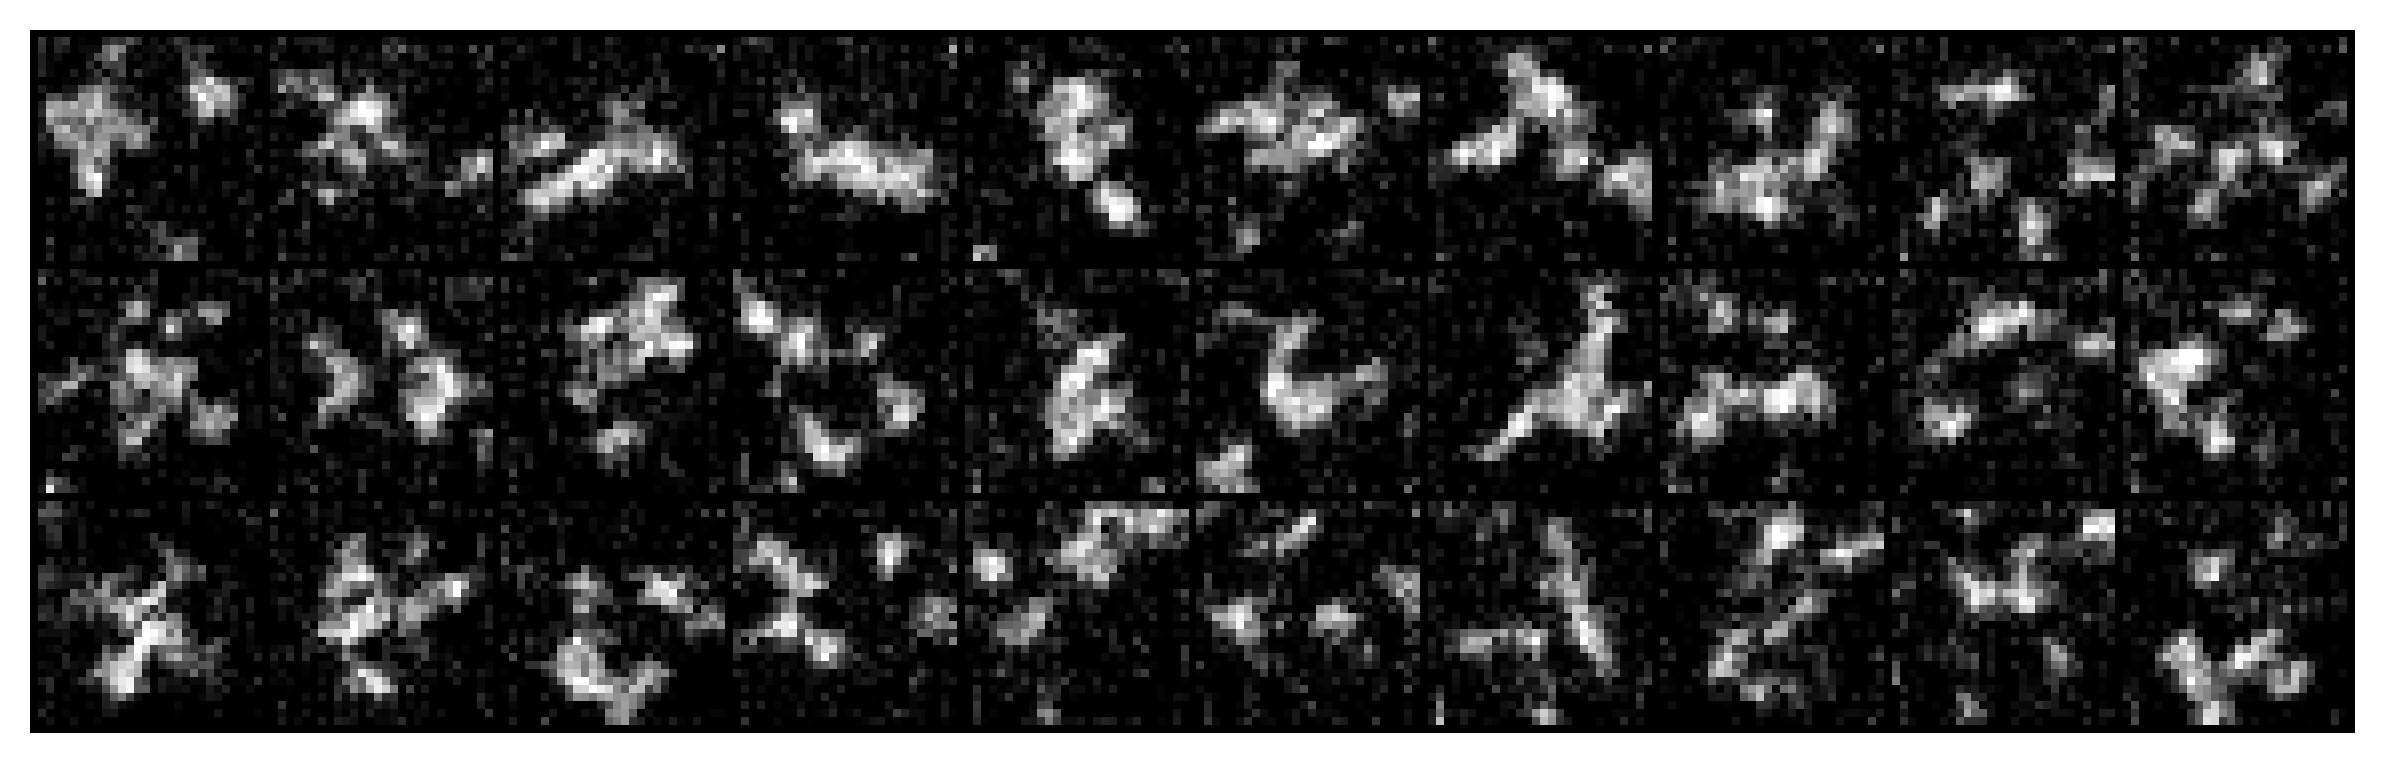

In [18]:
plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)

## Train Conditional Generation

In [19]:
model_type = "unet"    # "mlp" or "unet" or "dit"

if model_type == "unet":
    from rectified_flow.models.unet import SongUNet, SongUNetConfig
    config = SongUNetConfig(
        img_resolution = 28,
        in_channels = 1,                  # Number of color channels at input.
        out_channels = 1,                 # Number of color channels at output.
        label_dim = 10,                   # Number of class labels, 0 = unconditional.
        augment_dim = 0,                  # Augmentation label dimensionality, 0 = no augmentation.

        model_channels = 64,                # Base multiplier for the number of channels.
        channel_mult = [2, 2],              # Channel multipliers for each resolution.
        channel_mult_emb = 2,               # Multiplier for the dimensionality of the embedding vector.
        num_blocks = 2,                     # Number of residual blocks per resolution.
        attn_resolutions = [14],            # Resolutions at which to apply attention.
        dropout = 0.13,                     # Dropout probability of intermediate activations.
        label_dropout = 0.1,                # Dropout probability of class labels for classifier-free guidance.
        embedding_type = "positional",      # Timestep embedding type: 'positional' or 'fourier'.
        channel_mult_time = 1,              # Timestep embedding size: 1 for DDPM++, 2 for NCSN++.
        encoder_type = "standard",          # Encoder architecture: 'standard' or 'residual'.
        decoder_type = "standard",          # Decoder architecture: 'standard' or 'residual'.
        resample_filter = [1, 1]
    )
    flow_model = SongUNet(config)
    data_shape = (1, 28, 28)
elif model_type == "dit":
    raise NotImplementedError
else:
    raise ValueError(f"Unknown model type: {model_type}")

flow_model = flow_model.to(device)

print(f"Number of parameters in flow model: {sum(p.numel() for p in flow_model.parameters() if p.requires_grad):,}")

ema_flow = EMAModel(flow_model, ema_halflife_kimg=1.0, ema_rampup_ratio=0.05)

optimizer = torch.optim.AdamW(
    flow_model.parameters(),
    lr=5e-4, weight_decay=0.01,
    betas=(0.9, 0.95)
)

compiled_flow = flow_model

compiled_flow.train()
optimizer.zero_grad()

Number of parameters in flow model: 5,632,577


In [21]:
epoch = 30
cur_nimg = 0

epoch = 30
cur_nimg = 0

rf_train = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=compiled_flow,
    train_time_distribution="uniform",
    device=device,
)

try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm

def safe_tqdm_write(msg: str):
    try:
        tqdm.write(msg)
    except Exception:
        print(msg)

zero_to_none = True
grad_clip_norm = None

global_step = 0
running_loss = None
smooth_alpha = 0.99

# test model
with torch.no_grad():
    batch = next(iter(train_dataloader))
    x_1, c = batch
    x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
    c = c.to(device, non_blocking=True)
    c_onehot = torch.nn.functional.one_hot(c, num_classes=10).float()
    x_0 = torch.randn_like(x_1)
    t = rf_train.sample_train_time(x_1.shape[0]).to(device, non_blocking=True)
    # print(x_1.shape, x_0.shape, c.shape, t.shape)
    v_pred = flow_model(x_1, t, c_onehot)
    sq_err = (v_pred - (x_1 - x_0)).pow(2).sum(dim=1)
    loss = sq_err.mean()
    safe_tqdm_write(f"Initial test loss: {loss.item():.4f}")


Initial test loss: 1.9197


In [ ]:
for ep in tqdm(range(epoch), desc="Epochs", position=0):
    pbar = tqdm(train_dataloader, desc=f"ep {ep+1}/{epoch}", leave=False, position=1)
    epoch_loss = 0.0
    epoch_steps = 0

    for step, batch in enumerate(pbar):
        optimizer.zero_grad(set_to_none=zero_to_none)

        x_1, c = batch
        c_onehot = torch.nn.functional.one_hot(c, num_classes=10).float()
        c_onehot = c_onehot.to(device, non_blocking=True)

        x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
        x_0 = torch.randn_like(x_1)
        t = rf_train.sample_train_time(x_1.shape[0]).to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            x_t, dot_x_t = rf_train.get_interpolation(x_0=x_0, x_1=x_1, t=t)
            v_pred = rf_train.get_velocity(x_t, t, class_labels=c_onehot)

        loss = torch.nn.functional.mse_loss(v_pred.float(), dot_x_t.float())
        mse_loss = float(loss.detach().item())

        loss.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(rf_train.parameters(), grad_clip_norm)

        optimizer.step()

        global_step += 1
        cur_nimg += x_1.shape[0]
        ema_flow.update(cur_nimg=cur_nimg, batch_size=x_1.shape[0])

        loss_val = mse_loss
        epoch_loss += loss_val
        epoch_steps += 1
        running_loss = loss_val if running_loss is None else (
            smooth_alpha * running_loss + (1 - smooth_alpha) * mse_loss
        )

        pbar.set_postfix({
            "mse_loss": f"{mse_loss:.4f}",
            "mse_loss_ema": f"{running_loss:.4f}",
            "steps": global_step
        })

    avg_epoch_loss = epoch_loss / max(epoch_steps, 1)
    safe_tqdm_write(
        f"[epoch {ep+1}/{epoch}] steps={global_step:,} "
        f"epoch_loss={epoch_loss:.4f} avg_epoch_loss={avg_epoch_loss:.4f} "
        f"mse_loss_ema={running_loss:.4f}"
    )

    checkpoint_dir = "./checkpoints/flow_mnist_unet_conditional"
    os.makedirs(checkpoint_dir, exist_ok=True)
    if (ep + 1) % 5 == 0 or ep == epoch - 1:
        flow_model.save_pretrained(checkpoint_dir, filename=f"flow_mnist_unet_conditional_ep{ep+1}")
        ema_flow.save_pretrained(checkpoint_dir, filename=f"flow_mnist_unet_conditional_ep{ep+1}")

print(f"Training done. Total steps: {global_step:,}, last loss: {loss_val:.4f}, EMA: {running_loss:.4f}")


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

ep 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 1/30] steps=118 epoch_loss=63.8359 avg_epoch_loss=0.5410 mse_loss_ema=0.9296


ep 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 2/30] steps=236 epoch_loss=101.8933 avg_epoch_loss=0.8635 mse_loss_ema=0.9469


...

ep 24/30:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 24/30] steps=2,832 epoch_loss=150.8274 avg_epoch_loss=1.2782 mse_loss_ema=1.2766


ep 25/30:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 25/30] steps=2,950 epoch_loss=150.4629 avg_epoch_loss=1.2751 mse_loss_ema=1.2752
Configuration saved to ./checkpoints/flow_mnist_unet_conditional/flow_mnist_unet_conditional_ep25_config.json
Model weights saved to ./checkpoints/flow_mnist_unet_conditional/flow_mnist_unet_conditional_ep25_model.pt
EMA model weights saved to ./checkpoints/flow_mnist_unet_conditional/flow_mnist_unet_conditional_ep25_ema.pt


ep 26/30:   0%|          | 0/118 [00:00<?, ?it/s]

### Class Conditional Generation without CFG

In [ ]:

from rectified_flow.samplers import EulerSampler, SDESampler

# flow_model = SongUNet.from_pretrained(f"./checkpoints/flow_mnist_unet_conditional", use_ema=False).to(device)

model_inference = flow_model.eval()

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=model_inference,
    device=device,
)

# generate 100 samples for each class
class_labels = torch.arange(10, device=device)
class_labels = class_labels.repeat_interleave(10, dim=0)
class_onehot = torch.nn.functional.one_hot(class_labels, num_classes=10).float()

num_steps_list = [2, 5, 10, 20, 50, 100]
num_samples = 100

results = {}
for num_steps in num_steps_list:
    sampler = EulerSampler(rf_inference, num_steps=num_steps)
    generated = sampler.sample_loop(
        num_samples=num_samples,
        seed=33,
        class_labels=class_onehot,
    ).trajectories[-1]
    results[num_steps] = generated
    print(f"Generated with num_steps={num_steps}, shape={generated.shape}")

for num_steps, images in results.items():
    print(f"num_steps={num_steps}")
    plot_cifar_results(images)


In [ ]:
x_1_euler = euler_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]

print(x_1_euler.shape)  # torch.Size([20, 1, 28, 28])

In [ ]:
from rectified_flow.utils import plot_cifar_results

plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)

### Class Conditional Generation with CFG

In [ ]:
from rectified_flow.samplers import EulerSampler, SDESampler

flow_model = SongUNet.from_pretrained(f"./checkpoints/flow_mnist_unet_conditional", use_ema=True).to(device)

model_inference = flow_model.eval()

def velocity_with_cfg(x, t, class_labels=None, cfg_scale=3.5):
    assert class_labels is not None
    v_uncond = model_inference(x, t, torch.zeros_like(class_labels))
    v_cond = model_inference(x, t, class_labels)
    return cfg_scale * v_cond + (1. - cfg_scale) * v_uncond

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=velocity_with_cfg,
    device=device,
)

# generate 100 samples for each class
class_labels = torch.arange(10, device=device)
class_labels = class_labels.repeat_interleave(10, dim=0)
class_onehot = torch.nn.functional.one_hot(class_labels, num_classes=10).float()

cfg_scales = [0, 1, 2, 4, 7]
num_steps_list = [2, 5, 10, 20, 50, 100]
num_samples = 100

cfg_results = {}
for cfg_scale in cfg_scales:
    cfg_results[cfg_scale] = {}
    for num_steps in num_steps_list:
        sampler = EulerSampler(rf_inference, num_steps=num_steps)
        generated = sampler.sample_loop(
            num_samples=num_samples,
            seed=33,
            class_labels=class_onehot,
            cfg_scale=cfg_scale,
        ).trajectories[-1]
        cfg_results[cfg_scale][num_steps] = generated
        print(f"CFG scale={cfg_scale}, num_steps={num_steps}, shape={generated.shape}")

for cfg_scale, steps_dict in cfg_results.items():
    for num_steps, images in steps_dict.items():
        print(f"cfg_scale={cfg_scale}, num_steps={num_steps}")
        plot_cifar_results(images)


In [ ]:
x_1_euler = euler_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]

print(x_1_euler.shape)  # torch.Size([20, 1, 28, 28])

In [ ]:
from rectified_flow.utils import plot_cifar_results

plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)